#Assgn 6: Simple Neural Network Forward Propagation



#1. Load and prepare iris dataset

In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nDataset shape:", X.shape)

print("\nClasses:", iris.target_names)

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,target
0,0
1,0
2,0
3,0
4,0



Dataset shape: (150, 4)

Classes: ['setosa' 'versicolor' 'virginica']


#2. Split into Train/Test data and Normalization :

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


#3. Initilalizing Weight and Bias

In [3]:

np.random.seed(42)

input_neurons = 4
hidden_neurons = 5
output_neurons = 3

W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 5)
b1 shape: (1, 5)
W2 shape: (5, 3)
b2 shape: (1, 3)


#4. Defining Activation Function :  

In [4]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)


#5. Forward Propagation :

In [5]:
# Hidden layer
Z1 = np.dot(X_test, W1) + b1
A1 = relu(Z1)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)

# Output layer
Z2 = np.dot(A1, W2) + b2
A2 = softmax(Z2)

print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (30, 5)
A1 shape: (30, 5)
Z2 shape: (30, 3)
A2 shape: (30, 3)


#6. Predictions :

In [6]:
predictions = np.argmax(A2, axis=1)

print("Predicted classes:")
print(predictions)


predicted_species = iris.target_names[predictions]

print("\nPredicted Iris Species:")
print(predicted_species)

Predicted classes:
[2 1 2 0 2 1 2 2 1 0 1 1 1 1 2 2 2 0 1 1 2 1 2 0 1 1 2 2 1 2]

Predicted Iris Species:
['virginica' 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'versicolor' 'versicolor'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'virginica' 'versicolor' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'versicolor'
 'virginica']


#7. Display the prediction probabilities

In [13]:
results = pd.DataFrame(
    A2[:10],
    columns=[
        "Setosa Probability",
        "Versicolor Probability",
        "Virginica Probability"
    ]
)


results = results.round(4)

results["Predicted Class"] = predictions[:10]
results["Predicted Species"] = predicted_species[:10]

display(results)

,Setosa Probability,Versicolor Probability,Virginica Probability,Predicted Class,Predicted Species
0,0.0001,0.0000,0.9999,2,virginica
1,0.2205,0.4863,0.2932,1,versicolor
2,0.3501,0.2283,0.4216,2,virginica
3,0.3905,0.2456,0.3639,0,setosa
4,0.0000,0.0000,1.0000,2,virginica
5,0.1204,0.6474,0.2322,1,versicolor
6,0.0000,0.0000,1.0000,2,virginica
7,0.0000,0.0000,1.0000,2,virginica
8,0.1436,0.6139,0.2425,1,versicolor
9,0.3333,0.3333,0.3333,0,setosa


In [17]:
results = pd.DataFrame(
    A2[:10]*100,
    columns=[
        "Setosa Probability (%)",
        "Versicolor Probability (%)",
        "Virginica Probability (%)"
    ]
)


results = results.round(4)

results["Predicted Class"] = predictions[:10]
results["Predicted Species"] = predicted_species[:10]

display(results)

,Setosa Probability (%),Versicolor Probability (%),Virginica Probability (%),Predicted Class,Predicted Species
0,0.0116,0.0001,99.9883,2,virginica
1,22.0463,48.6317,29.3220,1,versicolor
2,35.0069,22.8332,42.1599,2,virginica
3,39.0513,24.5578,36.3910,0,setosa
4,0.0043,0.0001,99.9956,2,virginica
5,12.0373,64.7435,23.2192,1,versicolor
6,0.0001,0.0000,99.9999,2,virginica
7,0.0004,0.0000,99.9996,2,virginica
8,14.3617,61.3922,24.2461,1,versicolor
9,33.3333,33.3333,33.3333,0,setosa


#8. visualization of the output :

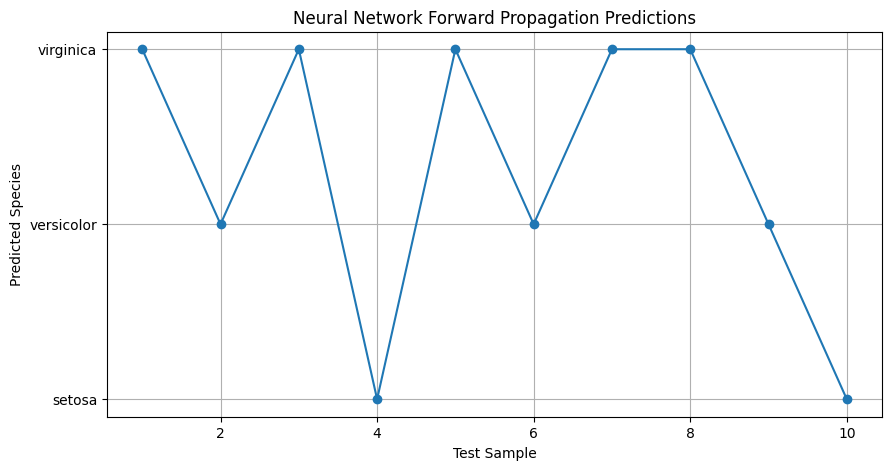

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 11),
    predictions[:10],
    marker='o'
)

plt.yticks(
    [0, 1, 2],
    iris.target_names
)

plt.xlabel("Test Sample")
plt.ylabel("Predicted Species")
plt.title("Neural Network Forward Propagation Predictions")
plt.grid(True)

plt.show()